
 10. Hashtag Analysis

 11. Emoji Analysis

 12. Top Words

 13. WordCloud

 14. Bigrams and Trigrams

 15. Outlier Analysis

 16. Correlation Analysis

 17. Findings and Conclusions

### 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [12]:
path = r"../data/raw/training.1600000.processed.noemoticon.csv"

data = pd.read_csv(path, encoding="latin1")

In [13]:
df = pd.DataFrame(data)
df.columns = ["Label", "Serial", "Date", "Query", "Twitter_id", "Tweet"]

### 3. Dataset Overview

In [14]:
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [15]:
df.tail()

,Label,Serial,Date,Query,Twitter_id,Tweet
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599998,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [16]:
df.shape

(1599999, 6)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Label       1599999 non-null  int64 
 1   Serial      1599999 non-null  int64 
 2   Date        1599999 non-null  object
 3   Query       1599999 non-null  object
 4   Twitter_id  1599999 non-null  object
 5   Tweet       1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [18]:
df.describe()

,Label,Serial
count,1.599999e+06,1.599999e+06
mean,2.000001e+00,1.998818e+09
std,2.000001e+00,1.935757e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.956916e+09
50%,4.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [19]:
df.describe(include="all")

,Label,Serial,Date,Query,Twitter_id,Tweet
count,1.599999e+06,1.599999e+06,1599999,1599999,1599999,1599999
unique,NaN,NaN,774362,1,659775,1581465
top,NaN,NaN,Mon Jun 15 12:53:14 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,NaN,NaN,20,1599999,549,210
mean,2.000001e+00,1.998818e+09,NaN,NaN,NaN,NaN
std,2.000001e+00,1.935757e+08,NaN,NaN,NaN,NaN
min,0.000000e+00,1.467811e+09,NaN,NaN,NaN,NaN
25%,0.000000e+00,1.956916e+09,NaN,NaN,NaN,NaN
50%,4.000000e+00,2.002102e+09,NaN,NaN,NaN,NaN
75%,4.000000e+00,2.177059e+09,NaN,NaN,NaN,NaN


### 4. Missing Values Analysis

In [20]:
df.isnull().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [21]:
df.isna().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [22]:
df["Tweet"].isnull()

0          False
1          False
2          False
3          False
4          False
           ...  
1599994    False
1599995    False
1599996    False
1599997    False
1599998    False
Name: Tweet, Length: 1599999, dtype: bool

In [23]:
df.notnull().sum()

Label         1599999
Serial        1599999
Date          1599999
Query         1599999
Twitter_id    1599999
Tweet         1599999
dtype: int64

In [24]:
df.isnull().sum(axis=1)
# df.isnull().sum(axis="rows")

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    0
1599996    0
1599997    0
1599998    0
Length: 1599999, dtype: int64

### 5. Class Distribution

In [25]:
df["Label"].value_counts()

Label
4    800000
0    799999
Name: count, dtype: int64

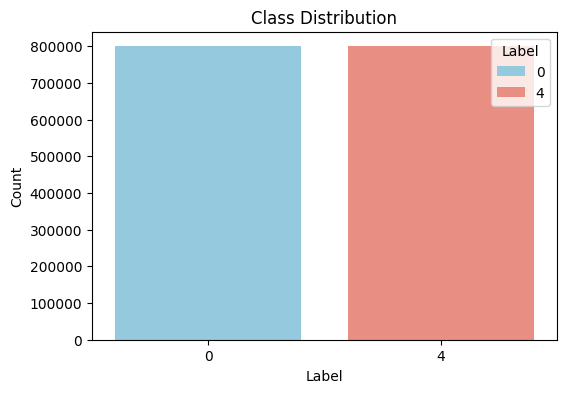

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, hue="Label", palette=["skyblue", "salmon"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### 6. Convert Labels

In [27]:
df.loc[df["Label"] == 4, "Label"] = 1

In [28]:
df["Label"].value_counts()

Label
1    800000
0    799999
Name: count, dtype: int64

### 7. Sample Tweets

In [29]:
df.loc[df["Label"] == 0, "Tweet"].sample(5)

674232          Is gonna be in pain today. )))) Noooooo... 
264720            I miss him, too. Gonna be a long 5 days. 
240547    @SuzyJHooker pepto x 10 it's been going on for...
58088     @stephenfry STEPHEN!! Ur pics are not go troug...
128088    stayed up to late watching tv. Getting the gir...
Name: Tweet, dtype: object

In [30]:
df.loc[df["Label"]==1, "Tweet"].sample(5)

940202     @DavidArchie love the kid... he was amazing  h...
1365359    Iron Maiden â The Evil That Men Do (Live) | ...
1582262    @Quaristice Re: Nolans the only thing that com...
1219805    Dear my new fellow followers, I'm not a wine, ...
1528028    @xxxZoexxx Yay, me too.....btw, on cheerier no...
Name: Tweet, dtype: object

### 8. Text Length Analysis

In [31]:
df["Length"] = df["Tweet"].str.len()
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29


In [32]:
data = df["Length"]

lenght_mean = np.mean(data)
print(f"{lenght_mean:.2f}")

74.09


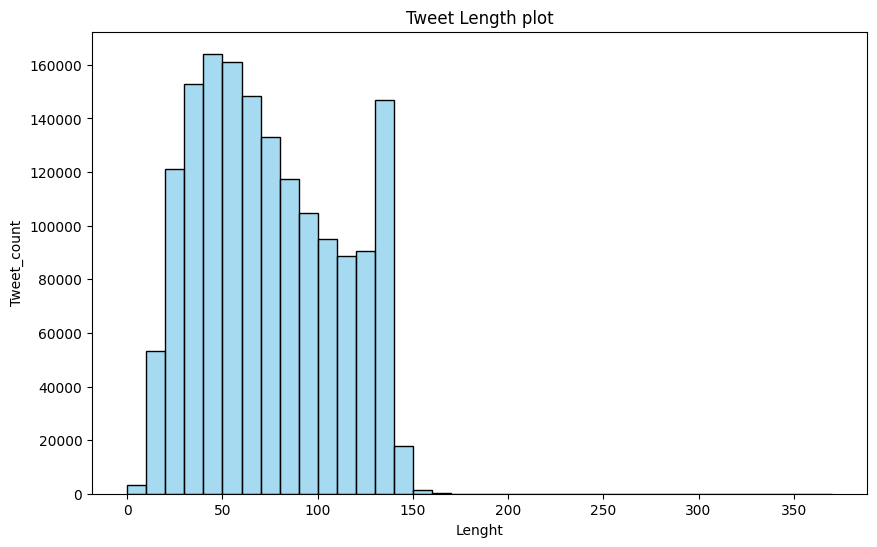

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df["Length"], color="skyblue", 
             bins=np.arange(0, df["Length"].max(), 10))
plt.title("Tweet Length plot")
plt.xlabel("Lenght")
plt.ylabel("Tweet_count")
plt.show()

In [34]:
max_length = df["Length"].max()
min_lenght = df["Length"].min()

print(f"The longest tweet has {max_length} words.")
print(f"The shortest tweet has {min_lenght} words.")

The longest tweet has 374 words.
The shortest tweet has 6 words.


### 9. Negative/Positive Distribution

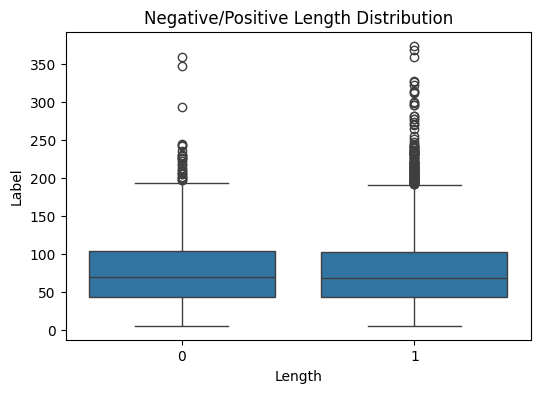

In [35]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Label", y="Length")
plt.title("Negative/Positive Length Distribution")
plt.xlabel("Length")
plt.ylabel("Label")
plt.show()

### 9. URL Analysis

In [36]:
url_pattern = r"https?://\S"

df["Url_Count"] = df["Tweet"].fillna("").str.count(url_pattern)

df["Url_Count"]

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    1
1599996    0
1599997    0
1599998    0
Name: Url_Count, Length: 1599999, dtype: int64

In [37]:
print(df["Url_Count"].describe())

count    1.599999e+06
mean     4.471440e-02
std      2.115244e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: Url_Count, dtype: float64


In [38]:
url_count = df["Url_Count"].gt(0).sum()
print(f"There are {url_count} Tweets with at least on url.")

There are 70110 Tweets with at least on url.


###  9. Mention Analysis

In [39]:
pattern = r"@\w+"

df["Mentions"] = df["Tweet"].fillna("").str.findall(pattern)

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei]


In [40]:
df["Mentions_Count"] = df["Mentions"].str.len()

In [41]:
mentions_count1 = df["Mentions_Count"].eq(1).sum()
mentions_count2 = df["Mentions_Count"].gt(1).sum()

print(f"There are {mentions_count1} tweets with exacly one mention.")
print(f"There are {mentions_count2} tweets with more than one mention.")

There are 704274 tweets with exacly one mention.
There are 34218 tweets with more than one mention.


In [42]:
negative_mentions_count = ((df["Label"]==0) & (df["Mentions_Count"]>0)).sum()
positive_mentions_count = ((df["Label"]==1) & (df["Mentions_Count"]>0)).sum()

print(f"Ther are {negative_mentions_count} negative tweets with at least one mention.")
print(f"Ther are {negative_mentions_count} positive tweets with at least one mention.")

Ther are 300841 negative tweets with at least one mention.
Ther are 300841 positive tweets with at least one mention.


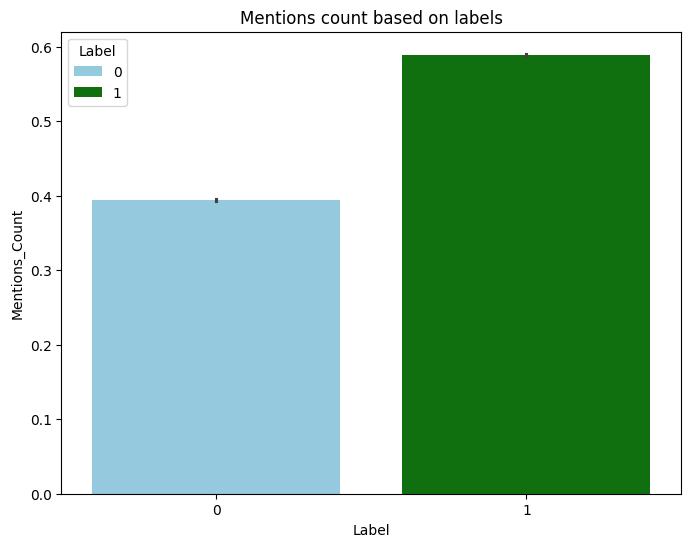

In [43]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Mentions_Count", hue="Label", palette=("skyblue", "green"))
plt.title("Mentions count based on labels")
plt.xlabel("Label")
plt.ylabel("Mentions_Count")
plt.show()